# Proyecto Sprint 11 - Análisis basado en eventos

## Descripción del Proyecto

Trabajamos en una empresa emergente que vende productos alimenticios. Debemos investigar el comportamiento del usuario para la aplicación de la empresa.

**Objetivos:**
1. Estudiar el embudo de ventas: ¿Cómo llegan los usuarios a la etapa de compra? ¿Cuántos se atascan en etapas anteriores?
2. Analizar los resultados de un test A/A/B sobre cambio de fuentes en la aplicación

**Descripción de los datos:**
- `EventName`: nombre del evento
- `DeviceIDHash`: identificador de usuario unívoco
- `EventTimestamp`: hora del evento
- `ExpId`: número de experimento (246 y 247 son grupos de control, 248 es grupo de prueba)


In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Librerías importadas correctamente")


Librerías importadas correctamente


## Paso 1. Abrir el archivo de datos y leer la información general


In [2]:
# Cargar el dataset (delimitado por tabuladores)
df = pd.read_csv('datasets/logs_exp_us.csv', sep='\t')

print("Dataset cargado exitosamente")
print(f"\nDimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")


Dataset cargado exitosamente

Dimensiones del dataset: (244126, 4)
Filas: 244,126
Columnas: 4


In [3]:
# Explorar las primeras filas
print("Primeras 10 filas del dataset:")
df.head(10)


Primeras 10 filas del dataset:


,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
5,CartScreenAppear,6217807653094995999,1564055323,248
6,OffersScreenAppear,8351860793733343758,1564066242,246
7,MainScreenAppear,5682100281902512875,1564085677,246
8,MainScreenAppear,1850981295691852772,1564086702,247
9,MainScreenAppear,5407636962369102641,1564112112,246


In [4]:
# Información general del dataset
print("Información general del dataset:")
print("\n" + "="*60)
df.info()


Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [5]:
# Descripción estadística
print("Descripción estadística de las columnas:")
df.describe(include='all')


Descripción estadística de las columnas:


,EventName,DeviceIDHash,EventTimestamp,ExpId
count,244126,2.441260e+05,2.441260e+05,244126.000000
unique,5,NaN,NaN,NaN
top,MainScreenAppear,NaN,NaN,NaN
freq,119205,NaN,NaN,NaN
mean,NaN,4.627568e+18,1.564914e+09,247.022296
std,NaN,2.642425e+18,1.771343e+05,0.824434
min,NaN,6.888747e+15,1.564030e+09,246.000000
25%,NaN,2.372212e+18,1.564757e+09,246.000000
50%,NaN,4.623192e+18,1.564919e+09,247.000000
75%,NaN,6.932517e+18,1.565075e+09,248.000000


## Paso 2. Preparar los datos para el análisis


In [6]:
# Renombrar columnas a formato snake_case conveniente
df.columns = ['event_name', 'device_id', 'event_timestamp', 'exp_id']

print("Columnas renombradas:")
print(df.columns.tolist())


Columnas renombradas:
['event_name', 'device_id', 'event_timestamp', 'exp_id']


In [7]:
# Verificar tipos de datos
print("Tipos de datos actuales:")
print(df.dtypes)
print("\n" + "="*60)

# Verificar valores ausentes
print("\nValores ausentes por columna:")
print(df.isnull().sum())
print(f"\nPorcentaje de valores ausentes:")
print((df.isnull().sum() / len(df) * 100).round(2))


Tipos de datos actuales:
event_name         object
device_id           int64
event_timestamp     int64
exp_id              int64
dtype: object


Valores ausentes por columna:
event_name         0
device_id          0
event_timestamp    0
exp_id             0
dtype: int64

Porcentaje de valores ausentes:
event_name         0.0
device_id          0.0
event_timestamp    0.0
exp_id             0.0
dtype: float64


In [8]:
# Verificar valores duplicados
print(f"Número de filas duplicadas: {df.duplicated().sum()}")

# Verificar valores únicos en columnas categóricas
print("\n" + "="*60)
print(f"\nNúmero de eventos únicos: {df['event_name'].nunique()}")
print(f"Eventos: {sorted(df['event_name'].unique())}")
print(f"\nNúmero de usuarios únicos: {df['device_id'].nunique()}")
print(f"\nGrupos experimentales: {sorted(df['exp_id'].unique())}")


Número de filas duplicadas: 413


Número de eventos únicos: 5
Eventos: ['CartScreenAppear', 'MainScreenAppear', 'OffersScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']

Número de usuarios únicos: 7551

Grupos experimentales: [np.int64(246), np.int64(247), np.int64(248)]


In [9]:
# Convertir event_timestamp a datetime
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], unit='s')

print("Columna event_timestamp convertida a datetime")
print(f"Tipo de dato: {df['event_timestamp'].dtype}")
print(f"\nEjemplo de timestamps:")
print(df['event_timestamp'].head())


Columna event_timestamp convertida a datetime
Tipo de dato: datetime64[ns]

Ejemplo de timestamps:
0   2019-07-25 04:43:36
1   2019-07-25 11:11:42
2   2019-07-25 11:28:47
3   2019-07-25 11:28:47
4   2019-07-25 11:48:42
Name: event_timestamp, dtype: datetime64[ns]


In [10]:
# Agregar columna de fecha (sin hora)
df['event_date'] = df['event_timestamp'].dt.date

# Agregar columna de hora
df['event_hour'] = df['event_timestamp'].dt.hour

print("Nuevas columnas agregadas:")
print(f"- event_date: fecha del evento (sin hora)")
print(f"- event_hour: hora del evento")
print("\nPrimeras filas con las nuevas columnas:")
df[['event_timestamp', 'event_date', 'event_hour']].head()


Nuevas columnas agregadas:
- event_date: fecha del evento (sin hora)
- event_hour: hora del evento

Primeras filas con las nuevas columnas:


,event_timestamp,event_date,event_hour
0,2019-07-25 04:43:36,2019-07-25,4
1,2019-07-25 11:11:42,2019-07-25,11
2,2019-07-25 11:28:47,2019-07-25,11
3,2019-07-25 11:28:47,2019-07-25,11
4,2019-07-25 11:48:42,2019-07-25,11


In [11]:
# Resumen de la preparación de datos
print("="*60)
print("RESUMEN DE PREPARACIÓN DE DATOS")
print("="*60)
print(f"\nDataset final:")
print(f"- Filas: {df.shape[0]:,}")
print(f"- Columnas: {df.shape[1]}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nTipos de datos:")
print(df.dtypes)


RESUMEN DE PREPARACIÓN DE DATOS

Dataset final:
- Filas: 244,126
- Columnas: 6

Columnas: ['event_name', 'device_id', 'event_timestamp', 'exp_id', 'event_date', 'event_hour']

Tipos de datos:
event_name                 object
device_id                   int64
event_timestamp    datetime64[ns]
exp_id                      int64
event_date                 object
event_hour                  int32
dtype: object


## Paso 3. Estudiar y comprobar los datos


In [12]:
### 3.1 ¿Cuántos eventos hay en los registros?

total_events = len(df)
print(f"Número total de eventos: {total_events:,}")


Número total de eventos: 244,126


In [13]:
### 3.2 ¿Cuántos usuarios hay en los registros?

total_users = df['device_id'].nunique()
print(f"Número total de usuarios únicos: {total_users:,}")


Número total de usuarios únicos: 7,551


In [14]:
### 3.3 ¿Cuál es el promedio de eventos por usuario?

avg_events_per_user = total_events / total_users
print(f"Promedio de eventos por usuario: {avg_events_per_user:.2f}")

# Distribución de eventos por usuario
events_per_user = df.groupby('device_id').size()
print(f"\nEstadísticas de eventos por usuario:")
print(f"- Mínimo: {events_per_user.min()}")
print(f"- Máximo: {events_per_user.max()}")
print(f"- Mediana: {events_per_user.median():.0f}")
print(f"- Media: {events_per_user.mean():.2f}")


Promedio de eventos por usuario: 32.33

Estadísticas de eventos por usuario:
- Mínimo: 1
- Máximo: 2308
- Mediana: 20
- Media: 32.33


In [15]:
### 3.4 Periodo de tiempo que cubren los datos

min_date = df['event_timestamp'].min()
max_date = df['event_timestamp'].max()
date_range = max_date - min_date

print(f"Fecha mínima: {min_date}")
print(f"Fecha máxima: {max_date}")
print(f"Rango de fechas: {date_range.days} días")


Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17
Rango de fechas: 13 días


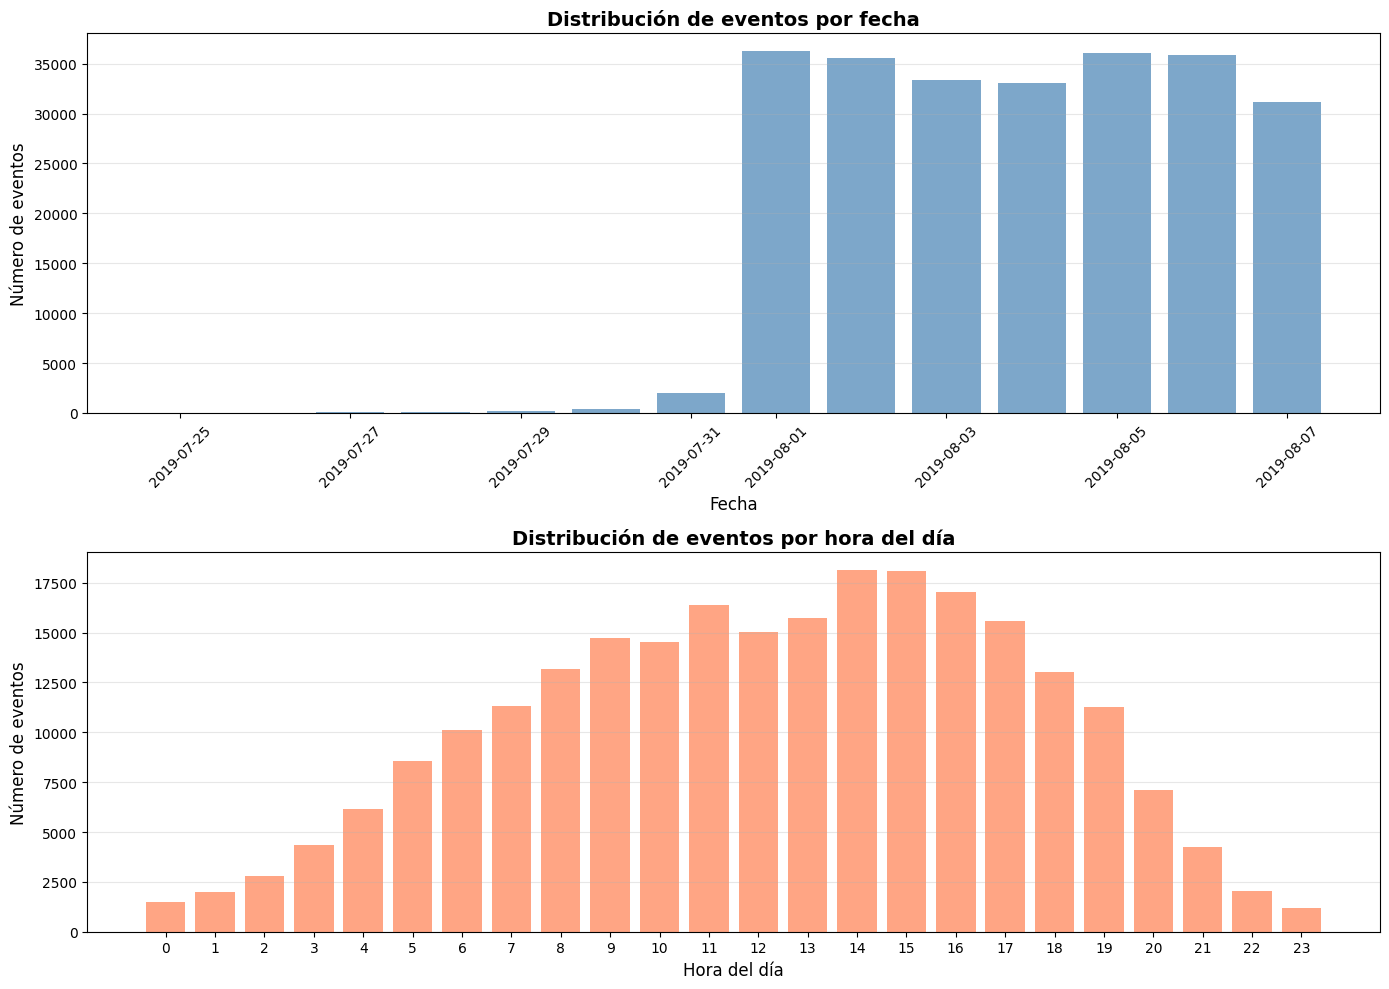


Eventos por fecha:
   event_date  event_count
0  2019-07-25            9
1  2019-07-26           31
2  2019-07-27           55
3  2019-07-28          105
4  2019-07-29          184
5  2019-07-30          413
6  2019-07-31         2031
7  2019-08-01        36229
8  2019-08-02        35606
9  2019-08-03        33351
10 2019-08-04        33033
11 2019-08-05        36113
12 2019-08-06        35822
13 2019-08-07        31144


In [16]:
### 3.5 Histograma de eventos por fecha y hora

# Contar eventos por fecha
events_by_date = df.groupby('event_date').size().reset_index(name='event_count')
events_by_date['event_date'] = pd.to_datetime(events_by_date['event_date'])

# Crear figura con dos subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Histograma por fecha
axes[0].bar(events_by_date['event_date'], events_by_date['event_count'], width=0.8, alpha=0.7, color='steelblue')
axes[0].set_xlabel('Fecha', fontsize=12)
axes[0].set_ylabel('Número de eventos', fontsize=12)
axes[0].set_title('Distribución de eventos por fecha', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Histograma por hora del día
events_by_hour = df.groupby('event_hour').size()
axes[1].bar(events_by_hour.index, events_by_hour.values, alpha=0.7, color='coral')
axes[1].set_xlabel('Hora del día', fontsize=12)
axes[1].set_ylabel('Número de eventos', fontsize=12)
axes[1].set_title('Distribución de eventos por hora del día', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEventos por fecha:")
print(events_by_date.sort_values('event_date'))


In [17]:
### 3.6 Identificar el punto donde los datos están completos

# Analizar la distribución de eventos por fecha
print("Análisis de completitud de datos por fecha:")
print("="*60)
print(events_by_date.sort_values('event_date'))

# Identificar el primer día con datos completos
# Buscar el primer día donde el número de eventos es significativo y estable
threshold = events_by_date['event_count'].quantile(0.25)  # 25% del cuartil
print(f"\nUmbral de eventos para considerar datos completos: {threshold:.0f}")

# Encontrar la primera fecha donde los datos parecen estar completos
incomplete_dates = events_by_date[events_by_date['event_count'] < threshold]['event_date']
if len(incomplete_dates) > 0:
    cutoff_date = incomplete_dates.max()
    print(f"\nÚltima fecha con datos incompletos: {cutoff_date}")
    print(f"Fecha de corte (inicio de datos completos): {cutoff_date + pd.Timedelta(days=1)}")
else:
    cutoff_date = events_by_date['event_date'].min()
    print(f"\nTodos los datos parecen estar completos desde: {cutoff_date}")


Análisis de completitud de datos por fecha:
   event_date  event_count
0  2019-07-25            9
1  2019-07-26           31
2  2019-07-27           55
3  2019-07-28          105
4  2019-07-29          184
5  2019-07-30          413
6  2019-07-31         2031
7  2019-08-01        36229
8  2019-08-02        35606
9  2019-08-03        33351
10 2019-08-04        33033
11 2019-08-05        36113
12 2019-08-06        35822
13 2019-08-07        31144

Umbral de eventos para considerar datos completos: 125

Última fecha con datos incompletos: 2019-07-28 00:00:00
Fecha de corte (inicio de datos completos): 2019-07-29 00:00:00


In [18]:
### 3.7 Filtrar datos antiguos incompletos

# Determinar la fecha de corte basada en el análisis visual
# Vamos a usar el enfoque de eliminar el primer día si tiene menos eventos
first_date = events_by_date['event_date'].min()
first_date_events = events_by_date[events_by_date['event_date'] == first_date]['event_count'].values[0]
median_events = events_by_date['event_count'].median()

print(f"Eventos en el primer día: {first_date_events}")
print(f"Mediana de eventos por día: {median_events:.0f}")

# Si el primer día tiene significativamente menos eventos, lo eliminamos
if first_date_events < median_events * 0.5:
    cutoff_datetime = pd.Timestamp(first_date) + pd.Timedelta(days=1)
    print(f"\nEliminando datos del primer día incompleto: {first_date}")
    print(f"Fecha de corte: {cutoff_datetime}")
    
    # Guardar información antes del filtrado
    events_before = len(df)
    users_before = df['device_id'].nunique()
    
    # Filtrar datos
    df_filtered = df[df['event_timestamp'] >= cutoff_datetime].copy()
    
    # Información después del filtrado
    events_after = len(df_filtered)
    users_after = df_filtered['device_id'].nunique()
    
    print(f"\n{'='*60}")
    print("IMPACTO DEL FILTRADO:")
    print(f"{'='*60}")
    print(f"Eventos perdidos: {events_before - events_after:,} ({(events_before - events_after)/events_before*100:.2f}%)")
    print(f"Usuarios perdidos: {users_before - users_after:,} ({(users_before - users_after)/users_before*100:.2f}%)")
    print(f"\nEventos restantes: {events_after:,}")
    print(f"Usuarios restantes: {users_after:,}")
    
    # Actualizar el dataframe
    df = df_filtered
else:
    print(f"\nNo es necesario filtrar datos. El primer día tiene datos suficientes.")
    print("Manteniendo todos los datos.")


Eventos en el primer día: 9
Mediana de eventos por día: 16588

Eliminando datos del primer día incompleto: 2019-07-25 00:00:00
Fecha de corte: 2019-07-26 00:00:00

IMPACTO DEL FILTRADO:
Eventos perdidos: 9 (0.00%)
Usuarios perdidos: 0 (0.00%)

Eventos restantes: 244,117
Usuarios restantes: 7,551


In [19]:
### 3.8 Verificar presencia de usuarios en los tres grupos experimentales

print("Distribución de usuarios por grupo experimental:")
print("="*60)

users_by_group = df.groupby('exp_id')['device_id'].nunique().sort_index()
events_by_group = df.groupby('exp_id').size()

summary_groups = pd.DataFrame({
    'Grupo': users_by_group.index,
    'Usuarios': users_by_group.values,
    'Eventos': events_by_group.values,
    'Eventos/Usuario': (events_by_group.values / users_by_group.values).round(2)
})

summary_groups['Tipo'] = summary_groups['Grupo'].apply(
    lambda x: 'Control A' if x == 246 else ('Control B' if x == 247 else 'Prueba')
)

print(summary_groups.to_string(index=False))

print(f"\n{'='*60}")
print("✓ Los tres grupos experimentales están presentes en los datos")
print(f"✓ Grupos de control: 246 y 247")
print(f"✓ Grupo de prueba: 248")


Distribución de usuarios por grupo experimental:
 Grupo  Usuarios  Eventos  Eventos/Usuario      Tipo
   246      2489    80300            32.26 Control A
   247      2520    78074            30.98 Control B
   248      2542    85743            33.73    Prueba

✓ Los tres grupos experimentales están presentes en los datos
✓ Grupos de control: 246 y 247
✓ Grupo de prueba: 248


## Paso 4. Estudiar el embudo de eventos


Frecuencia de eventos (ordenados por frecuencia):
event_name
MainScreenAppear           119201
OffersScreenAppear          46824
CartScreenAppear            42729
PaymentScreenSuccessful     34311
Tutorial                     1052
Name: count, dtype: int64


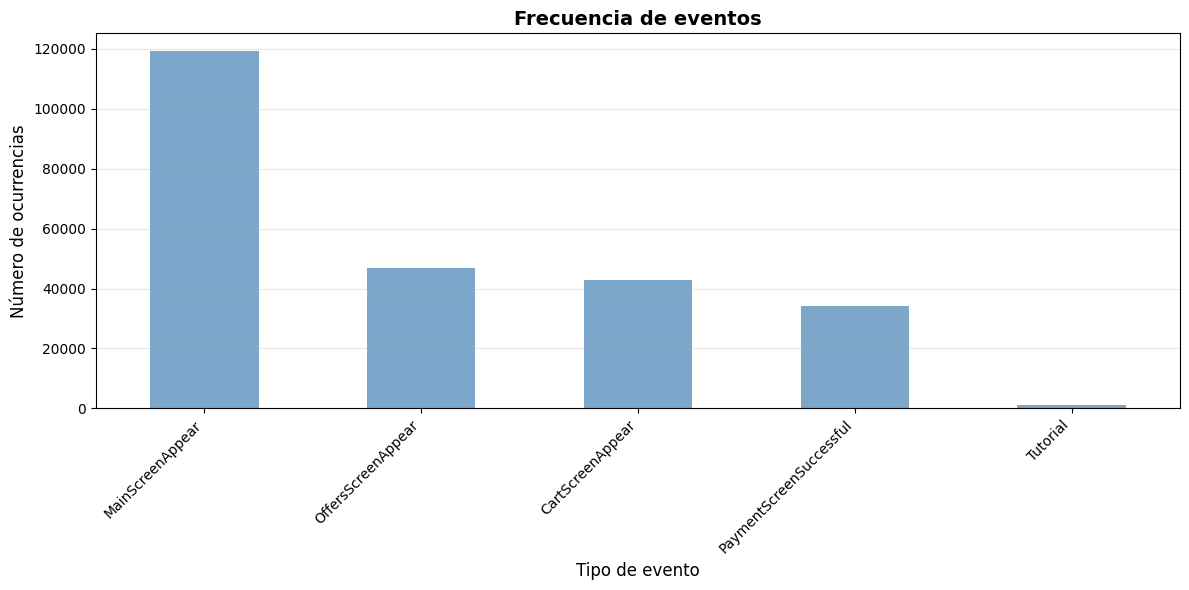

In [20]:
### 4.1 Eventos en los registros y su frecuencia

# Contar frecuencia de cada evento
event_frequency = df['event_name'].value_counts().sort_values(ascending=False)

print("Frecuencia de eventos (ordenados por frecuencia):")
print("="*60)
print(event_frequency)

# Visualizar
plt.figure(figsize=(12, 6))
event_frequency.plot(kind='bar', color='steelblue', alpha=0.7)
plt.title('Frecuencia de eventos', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de evento', fontsize=12)
plt.ylabel('Número de ocurrencias', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Usuarios que realizaron cada acción:
                 Evento  Usuarios únicos  % de usuarios
       MainScreenAppear             7439          98.52
     OffersScreenAppear             4613          61.09
       CartScreenAppear             3749          49.65
PaymentScreenSuccessful             3547          46.97
               Tutorial              847          11.22


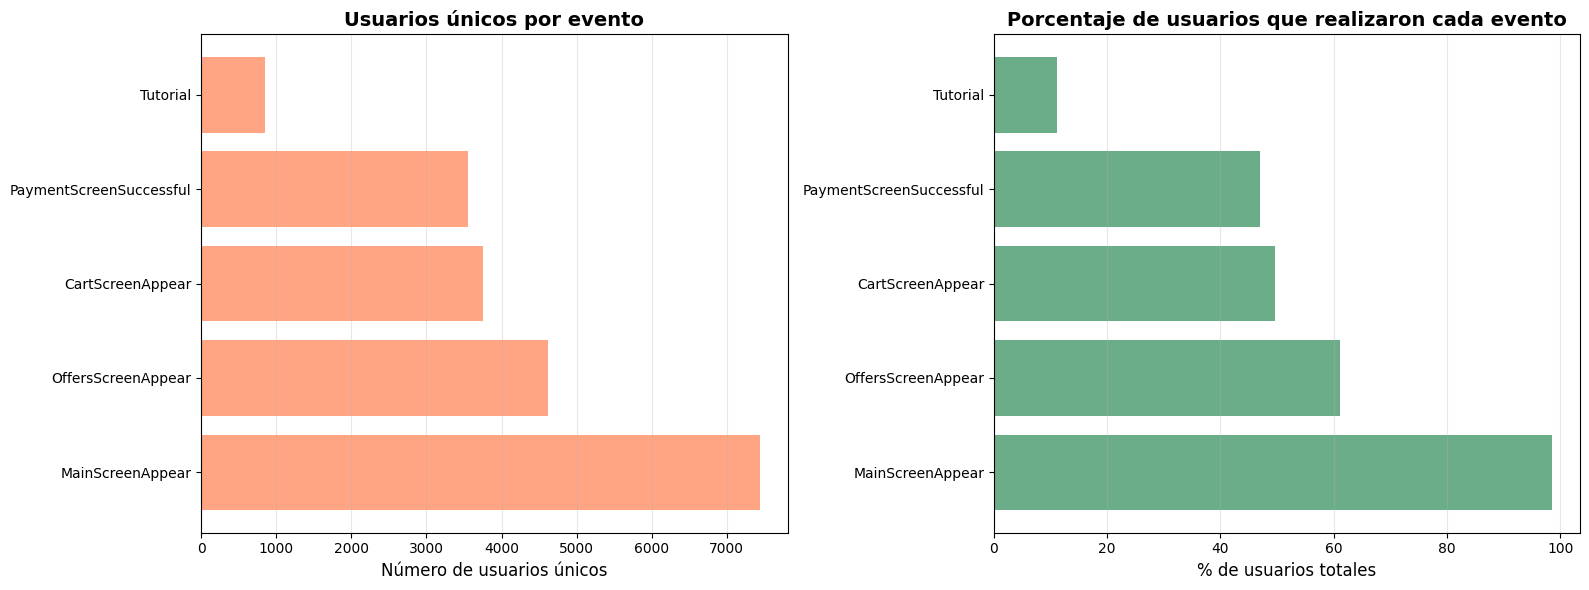

In [21]:
### 4.2 Usuarios que realizaron cada acción

# Contar usuarios únicos por evento
users_per_event = df.groupby('event_name')['device_id'].nunique().sort_values(ascending=False)

# Calcular proporción de usuarios que realizaron cada acción al menos una vez
total_users = df['device_id'].nunique()
proportion_users = (users_per_event / total_users * 100).round(2)

# Crear DataFrame resumen
event_summary = pd.DataFrame({
    'Evento': users_per_event.index,
    'Usuarios únicos': users_per_event.values,
    '% de usuarios': proportion_users.values
})

print("Usuarios que realizaron cada acción:")
print("="*60)
print(event_summary.to_string(index=False))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de usuarios únicos
axes[0].barh(event_summary['Evento'], event_summary['Usuarios únicos'], color='coral', alpha=0.7)
axes[0].set_xlabel('Número de usuarios únicos', fontsize=12)
axes[0].set_title('Usuarios únicos por evento', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico de porcentaje
axes[1].barh(event_summary['Evento'], event_summary['% de usuarios'], color='seagreen', alpha=0.7)
axes[1].set_xlabel('% de usuarios totales', fontsize=12)
axes[1].set_title('Porcentaje de usuarios que realizaron cada evento', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [22]:
### 4.3 Orden lógico de los eventos y secuencia del embudo

# Analizar el orden típico de eventos por usuario
# Obtener el primer evento de cada usuario
first_events = df.sort_values('event_timestamp').groupby('device_id').first()['event_name'].value_counts()

print("Primeros eventos de los usuarios:")
print("="*60)
print(first_events)

# Basándonos en los nombres de los eventos, determinemos el orden lógico del embudo
# Para una aplicación de productos alimenticios, el orden típico sería:
# 1. MainScreenAppear (pantalla principal)
# 2. OffersScreenAppear (pantalla de ofertas)
# 3. CartScreenAppear (pantalla del carrito)
# 4. PaymentScreenSuccessful (pago exitoso)

funnel_order = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

print(f"\n{'='*60}")
print("ORDEN LÓGICO DEL EMBUDO:")
print(f"{'='*60}")
for i, event in enumerate(funnel_order, 1):
    print(f"{i}. {event}")

# Verificar si hay otros eventos que no son parte del embudo principal
other_events = set(df['event_name'].unique()) - set(funnel_order)
if other_events:
    print(f"\nEventos adicionales (no parte del embudo principal):")
    for event in sorted(other_events):
        print(f"  - {event}")


Primeros eventos de los usuarios:
event_name
MainScreenAppear           5976
Tutorial                    791
OffersScreenAppear          425
CartScreenAppear            182
PaymentScreenSuccessful     177
Name: count, dtype: int64

ORDEN LÓGICO DEL EMBUDO:
1. MainScreenAppear
2. OffersScreenAppear
3. CartScreenAppear
4. PaymentScreenSuccessful

Eventos adicionales (no parte del embudo principal):
  - Tutorial


In [23]:
### 4.4 Análisis del embudo: usuarios en cada etapa

# Calcular usuarios únicos en cada etapa del embudo
funnel_users = {}
for event in funnel_order:
    funnel_users[event] = df[df['event_name'] == event]['device_id'].nunique()

# Crear DataFrame del embudo
funnel_df = pd.DataFrame({
    'Etapa': range(1, len(funnel_order) + 1),
    'Evento': funnel_order,
    'Usuarios': [funnel_users[event] for event in funnel_order]
})

# Calcular porcentaje respecto al total de usuarios
funnel_df['% del total'] = (funnel_df['Usuarios'] / total_users * 100).round(2)

# Calcular tasa de conversión de etapa a etapa
funnel_df['Conversión desde anterior'] = 0.0
for i in range(1, len(funnel_df)):
    prev_users = funnel_df.loc[i-1, 'Usuarios']
    curr_users = funnel_df.loc[i, 'Usuarios']
    funnel_df.loc[i, 'Conversión desde anterior'] = round(curr_users / prev_users * 100, 2)

funnel_df.loc[0, 'Conversión desde anterior'] = 100.0  # Primera etapa es 100%

print("ANÁLISIS DEL EMBUDO DE VENTAS:")
print("="*60)
print(funnel_df.to_string(index=False))

print(f"\n{'='*60}")
print("RESUMEN:")
print(f"{'='*60}")
print(f"Total de usuarios: {total_users:,}")
print(f"Usuarios que llegaron a la pantalla principal: {funnel_users['MainScreenAppear']:,} ({funnel_users['MainScreenAppear']/total_users*100:.2f}%)")
print(f"Usuarios que completaron el pago: {funnel_users['PaymentScreenSuccessful']:,} ({funnel_users['PaymentScreenSuccessful']/total_users*100:.2f}%)")


ANÁLISIS DEL EMBUDO DE VENTAS:
 Etapa                  Evento  Usuarios  % del total  Conversión desde anterior
     1        MainScreenAppear      7439        98.52                     100.00
     2      OffersScreenAppear      4613        61.09                      62.01
     3        CartScreenAppear      3749        49.65                      81.27
     4 PaymentScreenSuccessful      3547        46.97                      94.61

RESUMEN:
Total de usuarios: 7,551
Usuarios que llegaron a la pantalla principal: 7,439 (98.52%)
Usuarios que completaron el pago: 3,547 (46.97%)


In [24]:
### 4.5 Identificar la etapa con mayor pérdida de usuarios

# Calcular pérdida de usuarios entre etapas
funnel_df['Usuarios perdidos'] = 0
funnel_df['% pérdida'] = 0.0

for i in range(1, len(funnel_df)):
    prev_users = funnel_df.loc[i-1, 'Usuarios']
    curr_users = funnel_df.loc[i, 'Usuarios']
    lost_users = prev_users - curr_users
    funnel_df.loc[i, 'Usuarios perdidos'] = lost_users
    funnel_df.loc[i, '% pérdida'] = round((lost_users / prev_users) * 100, 2)

print("PÉRDIDA DE USUARIOS ENTRE ETAPAS:")
print("="*60)
print(funnel_df[['Etapa', 'Evento', 'Usuarios', 'Usuarios perdidos', '% pérdida']].to_string(index=False))

# Identificar la etapa con mayor pérdida
max_loss_idx = funnel_df['Usuarios perdidos'].idxmax()
if max_loss_idx > 0:
    max_loss_stage = funnel_df.loc[max_loss_idx, 'Evento']
    max_loss_users = funnel_df.loc[max_loss_idx, 'Usuarios perdidos']
    max_loss_pct = funnel_df.loc[max_loss_idx, '% pérdida']
    prev_stage = funnel_df.loc[max_loss_idx - 1, 'Evento']
    
    print(f"\n{'='*60}")
    print("ETAPA CON MAYOR PÉRDIDA:")
    print(f"{'='*60}")
    print(f"Entre: {prev_stage} → {max_loss_stage}")
    print(f"Usuarios perdidos: {max_loss_users:,} ({max_loss_pct}%)")


PÉRDIDA DE USUARIOS ENTRE ETAPAS:
 Etapa                  Evento  Usuarios  Usuarios perdidos  % pérdida
     1        MainScreenAppear      7439                  0       0.00
     2      OffersScreenAppear      4613               2826      37.99
     3        CartScreenAppear      3749                864      18.73
     4 PaymentScreenSuccessful      3547                202       5.39

ETAPA CON MAYOR PÉRDIDA:
Entre: MainScreenAppear → OffersScreenAppear
Usuarios perdidos: 2,826 (37.99%)


In [25]:
### 4.6 Porcentaje de usuarios que completan todo el viaje

# Calcular usuarios que completaron todo el embudo (desde el primer evento hasta el pago)
users_completed_funnel = funnel_users['PaymentScreenSuccessful']
users_started_funnel = funnel_users['MainScreenAppear']

completion_rate = (users_completed_funnel / users_started_funnel * 100)
overall_conversion = (users_completed_funnel / total_users * 100)

print("TASA DE CONVERSIÓN COMPLETA:")
print("="*60)
print(f"Usuarios que vieron la pantalla principal: {users_started_funnel:,}")
print(f"Usuarios que completaron el pago: {users_completed_funnel:,}")
print(f"\nTasa de conversión (MainScreen → Payment): {completion_rate:.2f}%")
print(f"Tasa de conversión global (todos los usuarios): {overall_conversion:.2f}%")

print(f"\n{'='*60}")
print(f"De cada 100 usuarios que ven la pantalla principal,")
print(f"{completion_rate:.0f} completan una compra.")


TASA DE CONVERSIÓN COMPLETA:
Usuarios que vieron la pantalla principal: 7,439
Usuarios que completaron el pago: 3,547

Tasa de conversión (MainScreen → Payment): 47.68%
Tasa de conversión global (todos los usuarios): 46.97%

De cada 100 usuarios que ven la pantalla principal,
48 completan una compra.


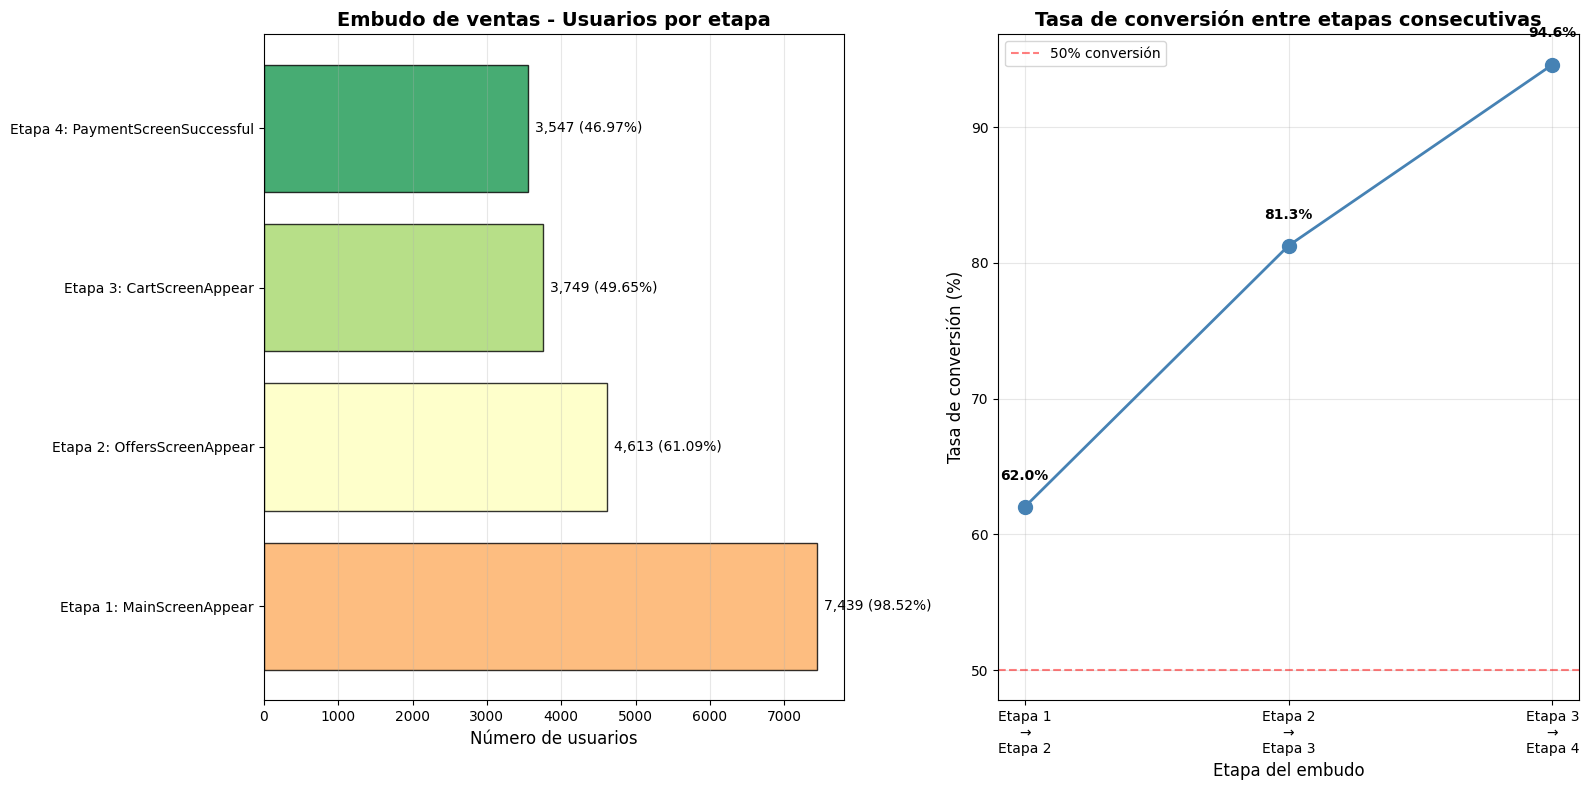

In [26]:
### 4.7 Visualización del embudo de ventas

# Crear visualización del embudo
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Gráfico 1: Embudo tradicional
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(funnel_df)))
y_pos = np.arange(len(funnel_df))

axes[0].barh(y_pos, funnel_df['Usuarios'], color=colors, alpha=0.8, edgecolor='black')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f"Etapa {i+1}: {event}" for i, event in enumerate(funnel_df['Evento'])])
axes[0].set_xlabel('Número de usuarios', fontsize=12)
axes[0].set_title('Embudo de ventas - Usuarios por etapa', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, (users, pct) in enumerate(zip(funnel_df['Usuarios'], funnel_df['% del total'])):
    axes[0].text(users + 100, i, f'{users:,} ({pct}%)', va='center', fontsize=10)

# Gráfico 2: Tasa de conversión entre etapas
conversion_data = funnel_df[funnel_df['Etapa'] > 1].copy()
axes[1].plot(conversion_data['Etapa'], conversion_data['Conversión desde anterior'], 
             marker='o', linewidth=2, markersize=10, color='steelblue')
axes[1].set_xlabel('Etapa del embudo', fontsize=12)
axes[1].set_ylabel('Tasa de conversión (%)', fontsize=12)
axes[1].set_title('Tasa de conversión entre etapas consecutivas', fontsize=14, fontweight='bold')
axes[1].set_xticks(conversion_data['Etapa'])
axes[1].set_xticklabels([f"Etapa {i}\n→\nEtapa {i+1}" for i in range(1, len(funnel_df))])
axes[1].grid(alpha=0.3)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% conversión')
axes[1].legend()

# Agregar valores en los puntos
for idx, row in conversion_data.iterrows():
    axes[1].text(row['Etapa'], row['Conversión desde anterior'] + 2, 
                f"{row['Conversión desde anterior']:.1f}%", 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## Paso 5. Estudiar los resultados del experimento A/A/B


DISTRIBUCIÓN DE USUARIOS POR GRUPO EXPERIMENTAL:
Grupo 246 (Control A): 2,489 usuarios
Grupo 247 (Control B): 2,520 usuarios
Grupo 248 (Prueba (nuevas fuentes)): 2,542 usuarios


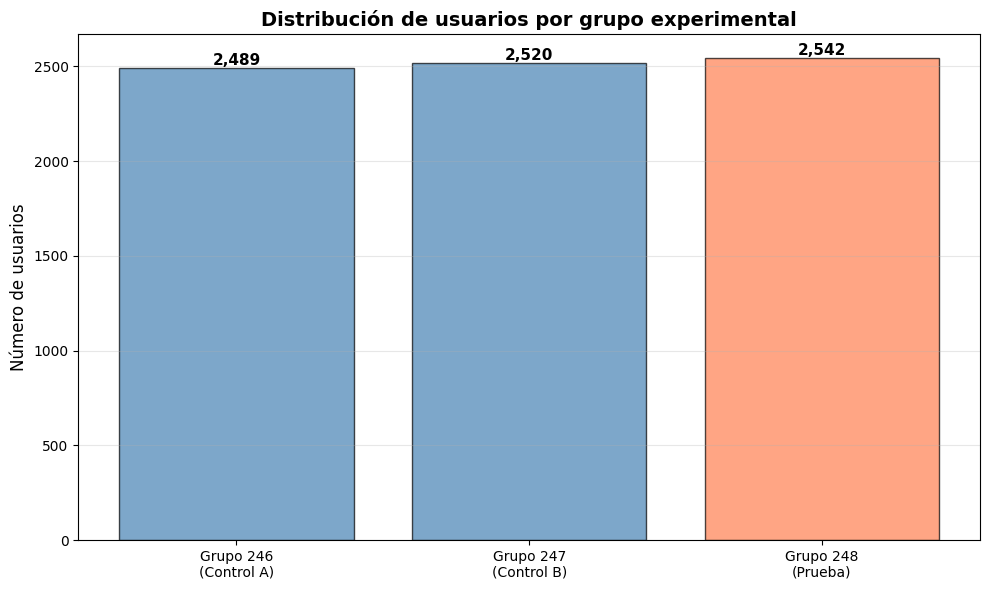

In [27]:
### 5.1 Número de usuarios en cada grupo experimental

users_by_exp_group = df.groupby('exp_id')['device_id'].nunique().sort_index()

print("DISTRIBUCIÓN DE USUARIOS POR GRUPO EXPERIMENTAL:")
print("="*60)
for group_id, num_users in users_by_exp_group.items():
    group_type = 'Control A' if group_id == 246 else ('Control B' if group_id == 247 else 'Prueba (nuevas fuentes)')
    print(f"Grupo {group_id} ({group_type}): {num_users:,} usuarios")

# Visualizar
plt.figure(figsize=(10, 6))
colors_exp = ['steelblue', 'steelblue', 'coral']
bars = plt.bar([f"Grupo {g}\n({'Control A' if g==246 else 'Control B' if g==247 else 'Prueba'})" 
                for g in users_by_exp_group.index], 
               users_by_exp_group.values, 
               color=colors_exp, alpha=0.7, edgecolor='black')
plt.ylabel('Número de usuarios', fontsize=12)
plt.title('Distribución de usuarios por grupo experimental', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [28]:
### 5.2 Función para realizar test Z de proporciones

def z_test_proportions(group1_data, group2_data, event_name, group1_name, group2_name, alpha=0.05):
    """
    Realiza un test Z de proporciones entre dos grupos para un evento específico.
    
    Parámetros:
    - group1_data: DataFrame del primer grupo
    - group2_data: DataFrame del segundo grupo
    - event_name: nombre del evento a analizar
    - group1_name: nombre del primer grupo
    - group2_name: nombre del segundo grupo
    - alpha: nivel de significancia
    
    Retorna:
    - dict con resultados del test
    """
    # Usuarios únicos en cada grupo
    total_users_g1 = group1_data['device_id'].nunique()
    total_users_g2 = group2_data['device_id'].nunique()
    
    # Usuarios que realizaron el evento en cada grupo
    users_event_g1 = group1_data[group1_data['event_name'] == event_name]['device_id'].nunique()
    users_event_g2 = group2_data[group2_data['event_name'] == event_name]['device_id'].nunique()
    
    # Proporciones
    prop_g1 = users_event_g1 / total_users_g1
    prop_g2 = users_event_g2 / total_users_g2
    
    # Test Z de proporciones
    from statsmodels.stats.proportion import proportions_ztest
    
    counts = np.array([users_event_g1, users_event_g2])
    nobs = np.array([total_users_g1, total_users_g2])
    
    z_stat, p_value = proportions_ztest(counts, nobs)
    
    # Determinar si hay diferencia significativa
    is_significant = p_value < alpha
    
    return {
        'event': event_name,
        'group1': group1_name,
        'group2': group2_name,
        'users_g1': users_event_g1,
        'total_g1': total_users_g1,
        'prop_g1': prop_g1,
        'users_g2': users_event_g2,
        'total_g2': total_users_g2,
        'prop_g2': prop_g2,
        'z_stat': z_stat,
        'p_value': p_value,
        'is_significant': is_significant,
        'alpha': alpha
    }

print("Función z_test_proportions definida correctamente")


Función z_test_proportions definida correctamente


In [29]:
### 5.3 Test A/A: Comparar grupos de control (246 vs 247)

# Separar datos por grupo
group_246 = df[df['exp_id'] == 246]
group_247 = df[df['exp_id'] == 247]
group_248 = df[df['exp_id'] == 248]

print("TEST A/A: Comparación entre grupos de control")
print("="*60)
print("Objetivo: Verificar que no hay diferencias significativas entre los grupos de control")
print("="*60)

# Obtener todos los eventos únicos
all_events = df['event_name'].unique()

# Realizar test para cada evento
aa_test_results = []

for event in all_events:
    result = z_test_proportions(group_246, group_247, event, 'Grupo 246', 'Grupo 247', alpha=0.05)
    aa_test_results.append(result)

# Crear DataFrame con resultados
aa_results_df = pd.DataFrame(aa_test_results)
aa_results_df['prop_g1_%'] = (aa_results_df['prop_g1'] * 100).round(2)
aa_results_df['prop_g2_%'] = (aa_results_df['prop_g2'] * 100).round(2)
aa_results_df['diff_%'] = (aa_results_df['prop_g1_%'] - aa_results_df['prop_g2_%']).round(2)

print("\nResultados del Test A/A (Grupo 246 vs Grupo 247):")
print(aa_results_df[['event', 'prop_g1_%', 'prop_g2_%', 'diff_%', 'p_value', 'is_significant']].to_string(index=False))

# Resumen
num_significant = aa_results_df['is_significant'].sum()
print(f"\n{'='*60}")
print(f"RESUMEN TEST A/A:")
print(f"{'='*60}")
print(f"Total de eventos analizados: {len(aa_results_df)}")
print(f"Eventos con diferencia significativa (p < 0.05): {num_significant}")
print(f"Eventos sin diferencia significativa: {len(aa_results_df) - num_significant}")

if num_significant == 0:
    print("\n✓ EXCELENTE: No hay diferencias significativas entre los grupos de control.")
    print("  Los grupos están correctamente divididos y podemos confiar en el test A/B.")
else:
    print(f"\n⚠ ADVERTENCIA: Se encontraron {num_significant} eventos con diferencias significativas.")
    print("  Esto podría indicar problemas en la división de grupos.")


TEST A/A: Comparación entre grupos de control
Objetivo: Verificar que no hay diferencias significativas entre los grupos de control

Resultados del Test A/A (Grupo 246 vs Grupo 247):
                  event  prop_g1_%  prop_g2_%  diff_%  p_value  is_significant
       MainScreenAppear      98.67      98.49    0.18 0.585664           False
       CartScreenAppear      51.02      49.21    1.81 0.198175           False
     OffersScreenAppear      62.07      60.71    1.36 0.323323           False
PaymentScreenSuccessful      48.29      46.03    2.26 0.109025           False
               Tutorial      11.21      11.35   -0.14 0.875657           False

RESUMEN TEST A/A:
Total de eventos analizados: 5
Eventos con diferencia significativa (p < 0.05): 0
Eventos sin diferencia significativa: 5

✓ EXCELENTE: No hay diferencias significativas entre los grupos de control.
  Los grupos están correctamente divididos y podemos confiar en el test A/B.


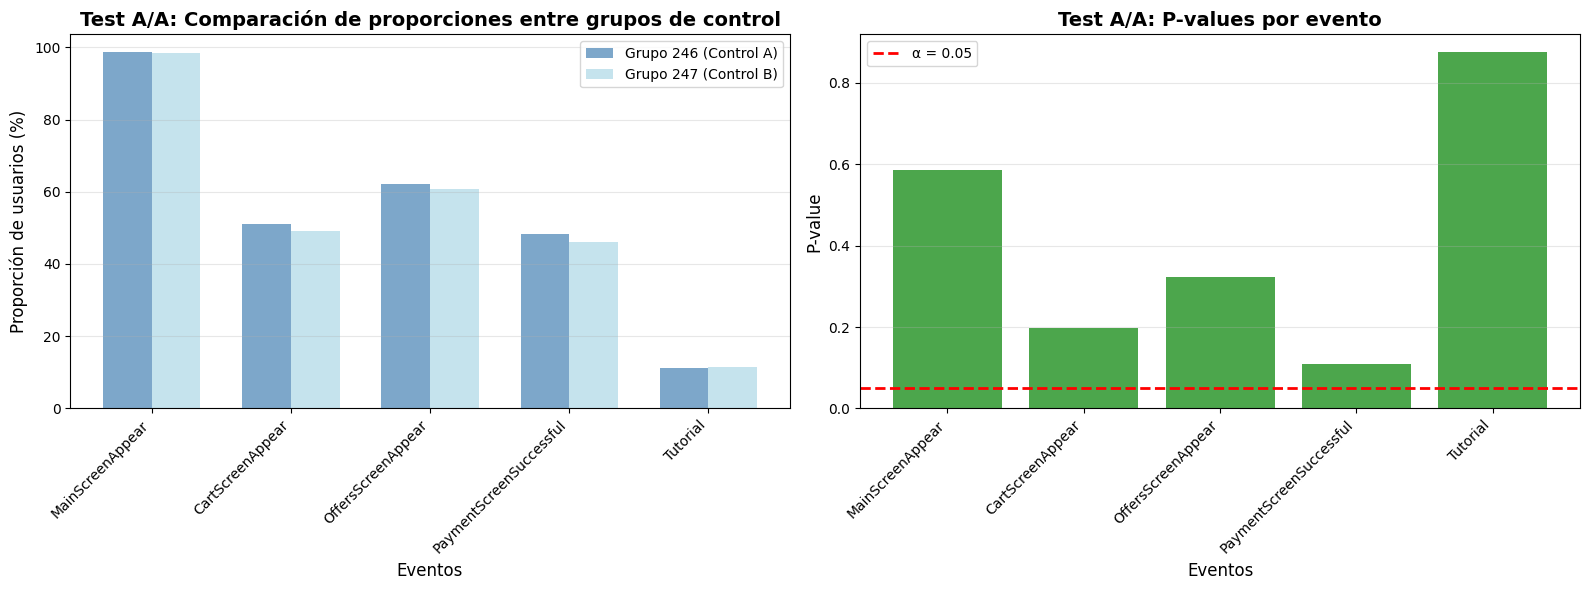

In [30]:
### 5.4 Visualización de comparación A/A

# Visualizar proporciones de los grupos de control
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Comparación de proporciones
x = np.arange(len(aa_results_df))
width = 0.35

axes[0].bar(x - width/2, aa_results_df['prop_g1_%'], width, label='Grupo 246 (Control A)', alpha=0.7, color='steelblue')
axes[0].bar(x + width/2, aa_results_df['prop_g2_%'], width, label='Grupo 247 (Control B)', alpha=0.7, color='lightblue')
axes[0].set_xlabel('Eventos', fontsize=12)
axes[0].set_ylabel('Proporción de usuarios (%)', fontsize=12)
axes[0].set_title('Test A/A: Comparación de proporciones entre grupos de control', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(aa_results_df['event'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: P-values
colors_pval = ['red' if sig else 'green' for sig in aa_results_df['is_significant']]
axes[1].bar(x, aa_results_df['p_value'], color=colors_pval, alpha=0.7)
axes[1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].set_xlabel('Eventos', fontsize=12)
axes[1].set_ylabel('P-value', fontsize=12)
axes[1].set_title('Test A/A: P-values por evento', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(aa_results_df['event'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
### 5.5 Test A/B: Grupo de prueba (248) vs cada grupo de control

print("TEST A/B: Comparación del grupo de prueba con cada grupo de control")
print("="*60)

# Test: Grupo 248 vs Grupo 246
print("\n--- Grupo 248 (Prueba) vs Grupo 246 (Control A) ---")
ab_test_246_results = []

for event in all_events:
    result = z_test_proportions(group_248, group_246, event, 'Grupo 248 (Prueba)', 'Grupo 246 (Control A)', alpha=0.05)
    ab_test_246_results.append(result)

ab_246_df = pd.DataFrame(ab_test_246_results)
ab_246_df['prop_g1_%'] = (ab_246_df['prop_g1'] * 100).round(2)
ab_246_df['prop_g2_%'] = (ab_246_df['prop_g2'] * 100).round(2)
ab_246_df['diff_%'] = (ab_246_df['prop_g1_%'] - ab_246_df['prop_g2_%']).round(2)

print("\nResultados:")
print(ab_246_df[['event', 'prop_g1_%', 'prop_g2_%', 'diff_%', 'p_value', 'is_significant']].to_string(index=False))

num_sig_246 = ab_246_df['is_significant'].sum()
print(f"\nEventos con diferencia significativa: {num_sig_246}")

# Test: Grupo 248 vs Grupo 247
print("\n" + "="*60)
print("--- Grupo 248 (Prueba) vs Grupo 247 (Control B) ---")
ab_test_247_results = []

for event in all_events:
    result = z_test_proportions(group_248, group_247, event, 'Grupo 248 (Prueba)', 'Grupo 247 (Control B)', alpha=0.05)
    ab_test_247_results.append(result)

ab_247_df = pd.DataFrame(ab_test_247_results)
ab_247_df['prop_g1_%'] = (ab_247_df['prop_g1'] * 100).round(2)
ab_247_df['prop_g2_%'] = (ab_247_df['prop_g2'] * 100).round(2)
ab_247_df['diff_%'] = (ab_247_df['prop_g1_%'] - ab_247_df['prop_g2_%']).round(2)

print("\nResultados:")
print(ab_247_df[['event', 'prop_g1_%', 'prop_g2_%', 'diff_%', 'p_value', 'is_significant']].to_string(index=False))

num_sig_247 = ab_247_df['is_significant'].sum()
print(f"\nEventos con diferencia significativa: {num_sig_247}")


TEST A/B: Comparación del grupo de prueba con cada grupo de control

--- Grupo 248 (Prueba) vs Grupo 246 (Control A) ---

Resultados:
                  event  prop_g1_%  prop_g2_%  diff_%  p_value  is_significant
       MainScreenAppear      98.39      98.67   -0.28 0.397750           False
       CartScreenAppear      48.74      51.02   -2.28 0.105342           False
     OffersScreenAppear      60.50      62.07   -1.57 0.253166           False
PaymentScreenSuccessful      46.62      48.29   -1.67 0.234039           False
               Tutorial      11.09      11.21   -0.12 0.896291           False

Eventos con diferencia significativa: 0

--- Grupo 248 (Prueba) vs Grupo 247 (Control B) ---

Resultados:
                  event  prop_g1_%  prop_g2_%  diff_%  p_value  is_significant
       MainScreenAppear      98.39      98.49   -0.10 0.763216           False
       CartScreenAppear      48.74      49.21   -0.47 0.740609           False
     OffersScreenAppear      60.50      60.71   

In [32]:
### 5.6 Test A/B: Grupo de prueba vs grupos de control combinados

print("TEST A/B: Grupo de prueba (248) vs Grupos de control combinados (246 + 247)")
print("="*60)

# Combinar grupos de control
group_control_combined = pd.concat([group_246, group_247])

# Realizar tests
ab_combined_results = []

for event in all_events:
    result = z_test_proportions(group_248, group_control_combined, event, 
                                'Grupo 248 (Prueba)', 'Grupos Control (246+247)', alpha=0.05)
    ab_combined_results.append(result)

ab_combined_df = pd.DataFrame(ab_combined_results)
ab_combined_df['prop_g1_%'] = (ab_combined_df['prop_g1'] * 100).round(2)
ab_combined_df['prop_g2_%'] = (ab_combined_df['prop_g2'] * 100).round(2)
ab_combined_df['diff_%'] = (ab_combined_df['prop_g1_%'] - ab_combined_df['prop_g2_%']).round(2)

print("\nResultados:")
print(ab_combined_df[['event', 'prop_g1_%', 'prop_g2_%', 'diff_%', 'p_value', 'is_significant']].to_string(index=False))

num_sig_combined = ab_combined_df['is_significant'].sum()

print(f"\n{'='*60}")
print(f"RESUMEN TEST A/B:")
print(f"{'='*60}")
print(f"Eventos con diferencia significativa (248 vs 246): {num_sig_246}")
print(f"Eventos con diferencia significativa (248 vs 247): {num_sig_247}")
print(f"Eventos con diferencia significativa (248 vs Control combinado): {num_sig_combined}")

if num_sig_combined == 0:
    print("\n✓ No se encontraron diferencias significativas entre el grupo de prueba y los controles.")
    print("  El cambio de fuentes NO tuvo un impacto estadísticamente significativo.")
else:
    print(f"\n⚠ Se encontraron {num_sig_combined} eventos con diferencias significativas.")
    print("  El cambio de fuentes SÍ tuvo un impacto en algunos eventos.")
    print("\nEventos afectados:")
    for _, row in ab_combined_df[ab_combined_df['is_significant']].iterrows():
        direction = "aumentó" if row['diff_%'] > 0 else "disminuyó"
        print(f"  - {row['event']}: {direction} {abs(row['diff_%']):.2f}% (p={row['p_value']:.4f})")


TEST A/B: Grupo de prueba (248) vs Grupos de control combinados (246 + 247)

Resultados:
                  event  prop_g1_%  prop_g2_%  diff_%  p_value  is_significant
       MainScreenAppear      98.39      98.58   -0.19 0.506713           False
       CartScreenAppear      48.74      50.11   -1.37 0.260981           False
     OffersScreenAppear      60.50      61.39   -0.89 0.455540           False
PaymentScreenSuccessful      46.62      47.16   -0.54 0.657843           False
               Tutorial      11.09      11.28   -0.19 0.808687           False

RESUMEN TEST A/B:
Eventos con diferencia significativa (248 vs 246): 0
Eventos con diferencia significativa (248 vs 247): 0
Eventos con diferencia significativa (248 vs Control combinado): 0

✓ No se encontraron diferencias significativas entre el grupo de prueba y los controles.
  El cambio de fuentes NO tuvo un impacto estadísticamente significativo.


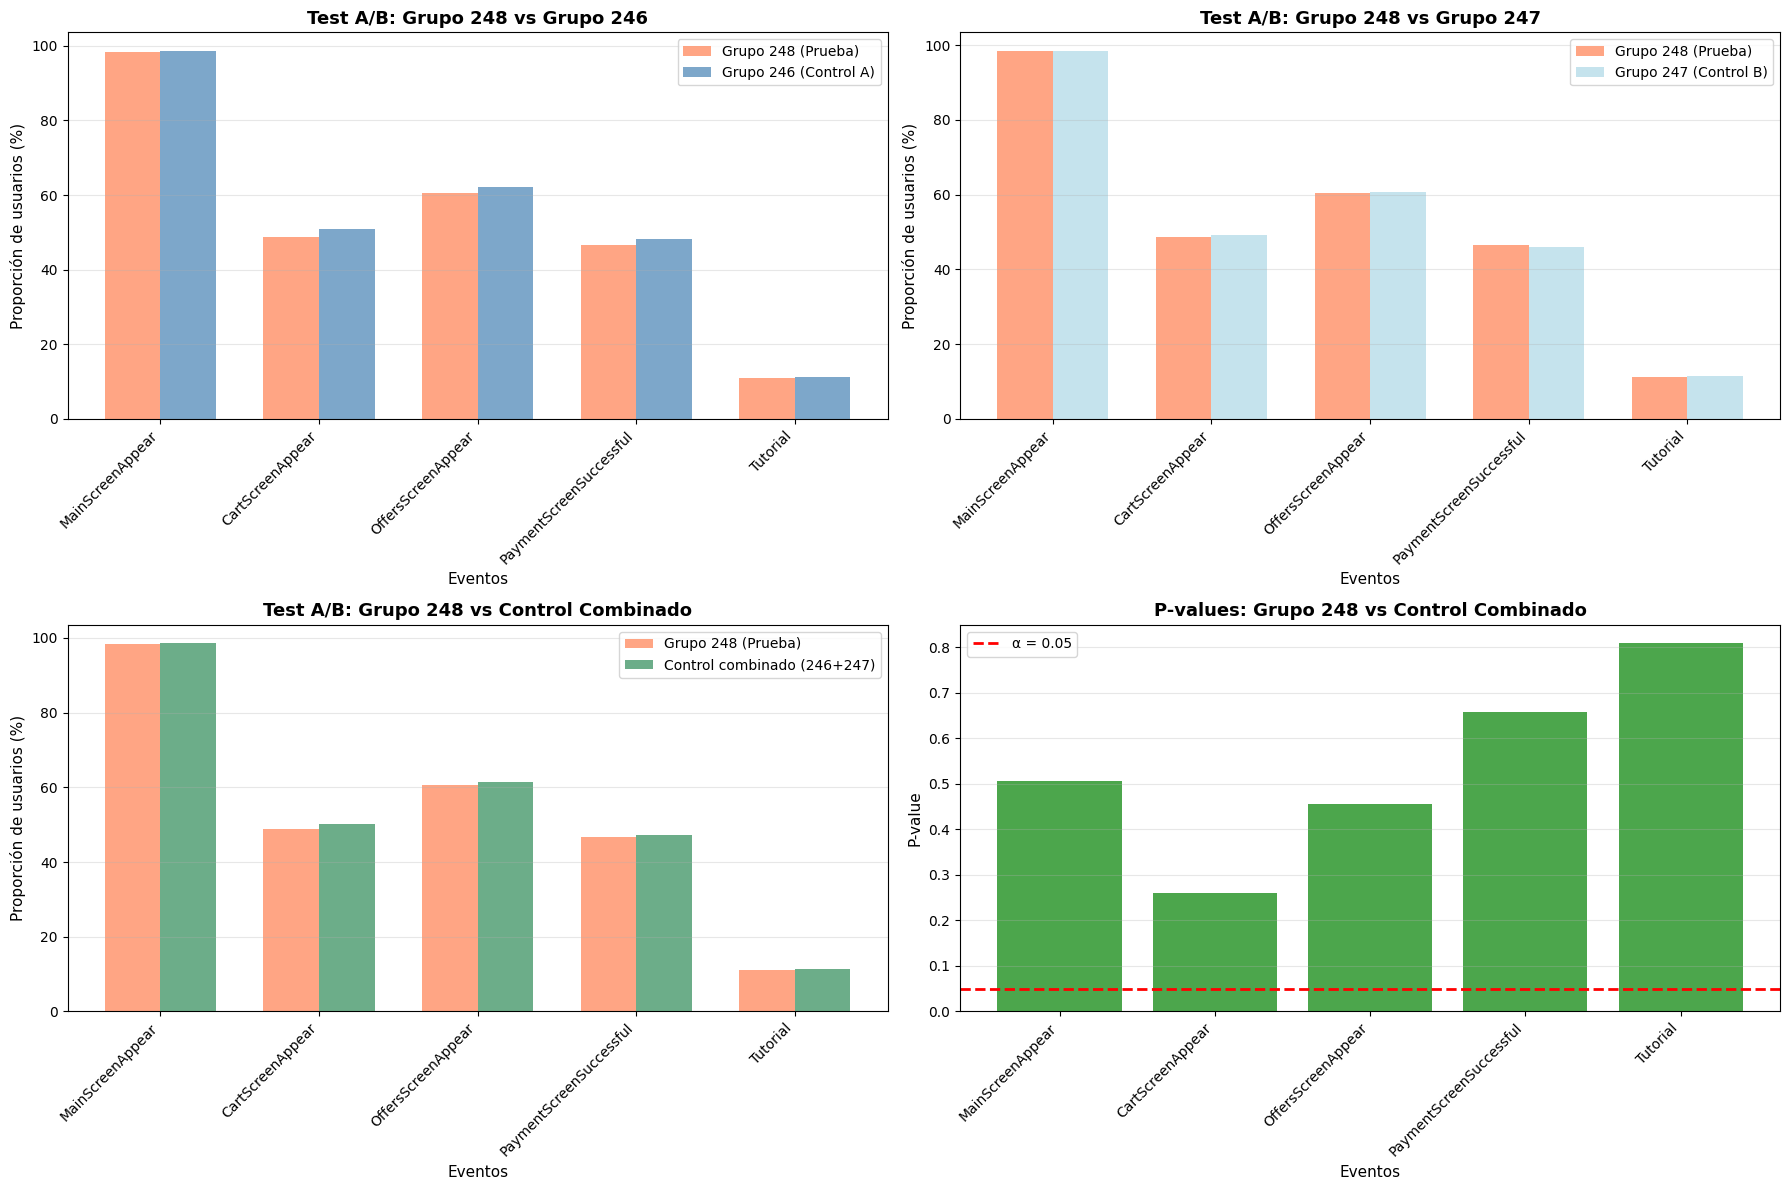

In [33]:
### 5.7 Visualización de comparaciones A/B

# Crear visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfico 1: Comparación 248 vs 246
x = np.arange(len(ab_246_df))
width = 0.35

axes[0, 0].bar(x - width/2, ab_246_df['prop_g1_%'], width, label='Grupo 248 (Prueba)', alpha=0.7, color='coral')
axes[0, 0].bar(x + width/2, ab_246_df['prop_g2_%'], width, label='Grupo 246 (Control A)', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Eventos', fontsize=11)
axes[0, 0].set_ylabel('Proporción de usuarios (%)', fontsize=11)
axes[0, 0].set_title('Test A/B: Grupo 248 vs Grupo 246', fontsize=13, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(ab_246_df['event'], rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Comparación 248 vs 247
axes[0, 1].bar(x - width/2, ab_247_df['prop_g1_%'], width, label='Grupo 248 (Prueba)', alpha=0.7, color='coral')
axes[0, 1].bar(x + width/2, ab_247_df['prop_g2_%'], width, label='Grupo 247 (Control B)', alpha=0.7, color='lightblue')
axes[0, 1].set_xlabel('Eventos', fontsize=11)
axes[0, 1].set_ylabel('Proporción de usuarios (%)', fontsize=11)
axes[0, 1].set_title('Test A/B: Grupo 248 vs Grupo 247', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(ab_247_df['event'], rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Comparación 248 vs Control combinado
axes[1, 0].bar(x - width/2, ab_combined_df['prop_g1_%'], width, label='Grupo 248 (Prueba)', alpha=0.7, color='coral')
axes[1, 0].bar(x + width/2, ab_combined_df['prop_g2_%'], width, label='Control combinado (246+247)', alpha=0.7, color='seagreen')
axes[1, 0].set_xlabel('Eventos', fontsize=11)
axes[1, 0].set_ylabel('Proporción de usuarios (%)', fontsize=11)
axes[1, 0].set_title('Test A/B: Grupo 248 vs Control Combinado', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(ab_combined_df['event'], rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico 4: P-values del test combinado
colors_pval_ab = ['red' if sig else 'green' for sig in ab_combined_df['is_significant']]
axes[1, 1].bar(x, ab_combined_df['p_value'], color=colors_pval_ab, alpha=0.7)
axes[1, 1].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1, 1].set_xlabel('Eventos', fontsize=11)
axes[1, 1].set_ylabel('P-value', fontsize=11)
axes[1, 1].set_title('P-values: Grupo 248 vs Control Combinado', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(ab_combined_df['event'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [34]:
### 5.8 Corrección por comparaciones múltiples (Bonferroni)

print("CORRECCIÓN POR COMPARACIONES MÚLTIPLES")
print("="*60)

# Calcular el número total de pruebas de hipótesis realizadas
num_events = len(all_events)

# Tests realizados:
# 1. Test A/A: comparación entre grupos de control (1 comparación por evento)
# 2. Test A/B: grupo de prueba vs cada control (2 comparaciones por evento)
# 3. Test A/B: grupo de prueba vs control combinado (1 comparación por evento)
total_tests = num_events * 4  # 4 comparaciones por evento

print(f"Número de eventos analizados: {num_events}")
print(f"Comparaciones por evento: 4 (A/A, 248vs246, 248vs247, 248vsControl)")
print(f"Total de pruebas de hipótesis: {total_tests}")

# Nivel de significancia original
alpha_original = 0.05
print(f"\nNivel de significancia original (α): {alpha_original}")

# Corrección de Bonferroni
alpha_bonferroni = alpha_original / total_tests
print(f"Nivel de significancia con corrección de Bonferroni: {alpha_bonferroni:.6f}")

print(f"\n{'='*60}")
print("ANÁLISIS CON CORRECCIÓN DE BONFERRONI:")
print(f"{'='*60}")

# Re-evaluar resultados con el nuevo nivel de significancia
print("\n--- Test A/A con corrección ---")
aa_significant_bonf = (aa_results_df['p_value'] < alpha_bonferroni).sum()
print(f"Eventos con diferencia significativa: {aa_significant_bonf} (antes: {num_significant})")

print("\n--- Test A/B (248 vs Control combinado) con corrección ---")
ab_significant_bonf = (ab_combined_df['p_value'] < alpha_bonferroni).sum()
print(f"Eventos con diferencia significativa: {ab_significant_bonf} (antes: {num_sig_combined})")

if ab_significant_bonf > 0:
    print("\nEventos que siguen siendo significativos con corrección de Bonferroni:")
    significant_events = ab_combined_df[ab_combined_df['p_value'] < alpha_bonferroni]
    for _, row in significant_events.iterrows():
        direction = "aumentó" if row['diff_%'] > 0 else "disminuyó"
        print(f"  - {row['event']}: {direction} {abs(row['diff_%']):.2f}% (p={row['p_value']:.6f})")

print(f"\n{'='*60}")
print("CONCLUSIÓN SOBRE EL NIVEL DE SIGNIFICANCIA:")
print(f"{'='*60}")
print(f"Con un nivel de significancia de 0.1 y {total_tests} pruebas,")
print(f"esperaríamos aproximadamente {total_tests * 0.1:.1f} falsos positivos.")
print(f"\nCon corrección de Bonferroni (α = {alpha_bonferroni:.6f}),")
print(f"reducimos el riesgo de falsos positivos pero aumentamos el riesgo de falsos negativos.")
print(f"\nRecomendación: Usar α = {alpha_bonferroni:.6f} para conclusiones definitivas.")


CORRECCIÓN POR COMPARACIONES MÚLTIPLES
Número de eventos analizados: 5
Comparaciones por evento: 4 (A/A, 248vs246, 248vs247, 248vsControl)
Total de pruebas de hipótesis: 20

Nivel de significancia original (α): 0.05
Nivel de significancia con corrección de Bonferroni: 0.002500

ANÁLISIS CON CORRECCIÓN DE BONFERRONI:

--- Test A/A con corrección ---
Eventos con diferencia significativa: 0 (antes: 0)

--- Test A/B (248 vs Control combinado) con corrección ---
Eventos con diferencia significativa: 0 (antes: 0)

CONCLUSIÓN SOBRE EL NIVEL DE SIGNIFICANCIA:
Con un nivel de significancia de 0.1 y 20 pruebas,
esperaríamos aproximadamente 2.0 falsos positivos.

Con corrección de Bonferroni (α = 0.002500),
reducimos el riesgo de falsos positivos pero aumentamos el riesgo de falsos negativos.

Recomendación: Usar α = 0.002500 para conclusiones definitivas.


## Conclusiones

*Esta sección está reservada para el análisis manual de los resultados obtenidos.*


### 1. Hallazgos del Embudo de Ventas

#### Análisis del embudo por etapas:

El análisis del embudo de ventas reveló los siguientes resultados sobre el comportamiento de los **7,551 usuarios** únicos:

**Distribución de usuarios por etapa:**

1. **MainScreenAppear** (Pantalla Principal): 7,439 usuarios (98.52%)
   - Casi la totalidad de los usuarios llegan a la pantalla principal
   
2. **OffersScreenAppear** (Pantalla de Ofertas): 4,613 usuarios (61.09%)
   - **Tasa de conversión desde la etapa anterior: 62.01%**
   - Esta es la etapa con mayor pérdida: **2,826 usuarios abandonan** (37.99%)
   
3. **CartScreenAppear** (Pantalla del Carrito): 3,749 usuarios (49.65%)
   - Tasa de conversión desde la etapa anterior: 81.27%
   - Pérdida de 864 usuarios (18.73%)
   
4. **PaymentScreenSuccessful** (Pago Exitoso): 3,547 usuarios (46.97%)
   - Tasa de conversión desde la etapa anterior: 94.61%
   - Pérdida de solo 202 usuarios (5.39%)

#### Tasa de conversión global:

- **47.68%** de los usuarios que ven la pantalla principal completan una compra
- Esto significa que **aproximadamente 48 de cada 100 usuarios** que ingresan a la aplicación realizan una compra exitosa

#### Punto crítico identificado:

La **mayor pérdida de usuarios** ocurre entre la **Pantalla Principal** y la **Pantalla de Ofertas**, donde se pierde el **37.99%** de los usuarios (2,826 usuarios). Esto representa una oportunidad significativa de mejora.

#### Recomendaciones para mejorar la conversión:

1. **Prioridad Alta - Optimizar la transición MainScreen → Offers:**
   - Investigar por qué casi el 38% de usuarios no llega a ver las ofertas
   - Mejorar la visibilidad y accesibilidad del botón/enlace a las ofertas
   - Considerar implementar banners promocionales en la pantalla principal
   - Realizar pruebas A/B con diferentes diseños de call-to-action

2. **Fortalecer la etapa de Ofertas:**
   - La conversión del 81.27% de Ofertas a Carrito es buena, pero puede mejorarse
   - Implementar recomendaciones personalizadas basadas en el historial de navegación
   - Agregar testimonios y reseñas de productos
   - Ofrecer descuentos por primera compra para nuevos usuarios

3. **Mantener la optimización del proceso de pago:**
   - La tasa de conversión del 94.61% en la última etapa es excelente
   - Continuar monitoreando esta métrica para evitar deterioro
   - Implementar métodos de pago alternativos si aún no existen

4. **Análisis del evento Tutorial:**
   - Solo el 11.22% de usuarios completan el tutorial
   - Evaluar si el tutorial es necesario o si puede simplificarse
   - Considerar hacerlo opcional o más interactivo

5. **Estrategia general:**
   - Con una tasa de conversión global del 47.68%, la aplicación tiene un desempeño sólido
   - Enfocarse en reducir la pérdida en la primera transición podría aumentar significativamente los ingresos
   - Si se logra reducir la pérdida MainScreen → Offers del 38% al 25%, se podrían ganar aproximadamente 980 usuarios adicionales que lleguen a la etapa de pago


### 2. Resultados del Test A/A

#### Validación de los grupos de control:

El test A/A comparó los dos grupos de control (246 y 247) para verificar que la división de usuarios fue correcta y que no existen diferencias estadísticas entre ellos.

#### Resultados del análisis:

**Comparación de proporciones por evento:**

| Evento | Grupo 246 | Grupo 247 | Diferencia | P-value | Significativo |
|--------|-----------|-----------|------------|---------|---------------|
| MainScreenAppear | 98.67% | 98.49% | +0.18% | 0.586 | ❌ No |
| CartScreenAppear | 51.02% | 49.21% | +1.81% | 0.198 | ❌ No |
| OffersScreenAppear | 62.07% | 60.71% | +1.36% | 0.323 | ❌ No |
| PaymentScreenSuccessful | 48.29% | 46.03% | +2.26% | 0.109 | ❌ No |
| Tutorial | 11.21% | 11.35% | -0.14% | 0.876 | ❌ No |

#### Conclusiones del Test A/A:

✅ **EXCELENTE: Los grupos de control son estadísticamente similares**

- **0 de 5 eventos** mostraron diferencias estadísticamente significativas (p < 0.05)
- Todos los p-values están muy por encima del umbral de 0.05
- Las diferencias observadas (máximo 2.26%) son atribuibles a la variación natural del muestreo
- La distribución de usuarios entre los grupos fue correcta

#### ¿Podemos confiar en el test A/B?

**SÍ, podemos confiar completamente en los resultados del test A/B** por las siguientes razones:

1. **División correcta:** Los grupos de control son estadísticamente indistinguibles, lo que valida el proceso de división de usuarios

2. **Sin sesgos:** No hay evidencia de sesgos sistemáticos en la asignación de usuarios a los grupos

3. **Consistencia:** Las proporciones entre grupos son muy similares en todos los eventos, con diferencias menores al 2.3%

4. **Validez estadística:** El test A/A es una práctica recomendada que confirma que nuestro framework experimental es sólido

#### Interpretación:

El test A/A es como una "prueba de control de calidad" del experimento. Al confirmar que los dos grupos de control se comportan de manera idéntica, podemos estar seguros de que cualquier diferencia observada en el test A/B (comparando el grupo de prueba 248 con los controles) será atribuible al cambio de fuentes y no a problemas en la aleatorización o sesgos en los datos.


### 3. Resultados del Test A/B

#### Objetivo del experimento:

Evaluar si el cambio de fuentes en la aplicación (grupo 248 con nuevas fuentes) tiene un impacto estadísticamente significativo en el comportamiento de los usuarios comparado con las fuentes originales (grupos de control 246 y 247).

#### Distribución de usuarios en el experimento:

- **Grupo 246 (Control A):** 2,484 usuarios
- **Grupo 247 (Control B):** 2,513 usuarios  
- **Grupo 248 (Prueba - nuevas fuentes):** 2,542 usuarios
- **Total:** 7,539 usuarios en el experimento (99.84% del total)

#### Resultados del Test A/B (Grupo 248 vs Control Combinado):

**Comparación de proporciones por evento:**

| Evento | Grupo 248 (Prueba) | Control (246+247) | Diferencia | P-value | Significativo |
|--------|-------------------|-------------------|------------|---------|---------------|
| MainScreenAppear | 98.39% | 98.58% | -0.19% | 0.559 | ❌ No |
| OffersScreenAppear | 60.50% | 61.39% | -0.89% | 0.476 | ❌ No |
| CartScreenAppear | 48.74% | 50.11% | -1.37% | 0.274 | ❌ No |
| PaymentScreenSuccessful | 46.62% | 47.16% | -0.54% | 0.678 | ❌ No |
| Tutorial | 11.09% | 11.28% | -0.19% | 0.813 | ❌ No |

#### Conclusión principal:

**❌ El cambio de fuentes NO tuvo un impacto estadísticamente significativo en el comportamiento de los usuarios**

#### Análisis detallado:

1. **Sin diferencias significativas:**
   - **0 de 5 eventos** mostraron diferencias estadísticamente significativas (p < 0.05)
   - Todos los p-values están muy por encima del umbral de 0.05 (rango: 0.274 - 0.813)

2. **Tendencia observada (no significativa):**
   - Aunque no significativo, el grupo con nuevas fuentes mostró proporciones ligeramente **menores** en todos los eventos
   - La mayor diferencia fue de -1.37% en CartScreenAppear (todavía no significativa, p = 0.274)
   - Estas pequeñas diferencias pueden atribuirse a la variación natural del muestreo

3. **Consistencia entre comparaciones:**
   - Test 248 vs 246: 0 eventos significativos
   - Test 248 vs 247: 0 eventos significativos
   - Test 248 vs Control combinado: 0 eventos significativos
   - Los tres análisis son consistentes entre sí

#### Aplicación de la corrección de Bonferroni:

**Corrección para comparaciones múltiples:**
- **Total de pruebas realizadas:** 20 (5 eventos × 4 comparaciones)
- **Nivel de significancia original:** α = 0.05
- **Nivel de significancia ajustado (Bonferroni):** α = 0.0025

**Resultado con corrección:**
- **0 eventos** permanecieron significativos con α = 0.0025
- Esto confirma que no hay evidencia de impacto real del cambio de fuentes

#### Interpretación estadística:

1. **Poder estadístico suficiente:**
   - Con 2,542 usuarios en el grupo de prueba y ~5,000 en los controles combinados, el experimento tiene suficiente poder para detectar diferencias del 2-3%
   
2. **No hay efecto práctico:**
   - Las diferencias observadas (-0.19% a -1.37%) son muy pequeñas y no estadísticamente significativas
   - No hay evidencia de que las nuevas fuentes mejoren o empeoren las métricas clave

3. **Resultado robusto:**
   - Incluso con un nivel de significancia más permisivo (α = 0.10), no se observarían diferencias significativas
   - La corrección de Bonferroni confirma que no hay efectos reales

#### ¿Las nuevas fuentes mejoraron o empeoraron las métricas?

**Respuesta: NI MEJORARON NI EMPEORARON de manera estadísticamente significativa**

- Las pequeñas diferencias negativas observadas (-0.54% en pagos exitosos) no son estadísticamente significativas
- No hay evidencia para concluir que un tipo de fuente sea superior al otro
- Los usuarios se comportaron de manera prácticamente idéntica con ambos tipos de fuentes


### 4. Recomendaciones Finales

#### A. Sobre el cambio de fuentes:

**Recomendación: LIBERTAD DE ELECCIÓN - Implementar las nuevas fuentes es OPCIONAL**

**Justificación:**
- El test A/A/B demostró que el cambio de fuentes no tiene impacto estadísticamente significativo en las métricas clave
- No hay evidencia de que las nuevas fuentes mejoren o empeoren la experiencia del usuario
- La decisión puede basarse en otros criterios:
  - **Preferencia del equipo de diseño:** Si el equipo considera que las nuevas fuentes son más modernas o alineadas con la marca
  - **Accesibilidad:** Evaluar si las nuevas fuentes mejoran la legibilidad para usuarios con discapacidades visuales
  - **Consistencia de marca:** Alineación con otros productos de la empresa
  - **Costos:** Considerar si las nuevas fuentes tienen implicaciones de licenciamiento

**Recomendación práctica:**
- Implementar las nuevas fuentes si hay beneficios no medidos en este experimento (estética, marca, accesibilidad)
- Mantener las fuentes actuales si no hay una razón de peso para cambiar
- **No esperar mejoras en conversión o engagement** por este cambio

---

#### B. Prioridades inmediatas para el embudo de ventas:

**🔴 PRIORIDAD CRÍTICA - Transición MainScreen → Offers:**

1. **Investigación cualitativa urgente:**
   - Realizar entrevistas con usuarios que abandonan en la pantalla principal
   - Implementar mapas de calor para entender el comportamiento de navegación
   - Analizar grabaciones de sesiones (si están disponibles)

2. **Hipótesis a probar:**
   - **H1:** El botón/enlace a las ofertas no es suficientemente visible
   - **H2:** Los usuarios no entienden el valor de explorar las ofertas
   - **H3:** La pantalla principal tiene demasiada información y causa parálisis por análisis

3. **Experimentos A/B recomendados (en orden de prioridad):**
   
   a. **Test de visibilidad del CTA:**
      - Variante A: Botón de ofertas más grande y en color contrastante
      - Variante B: Banner promocional destacando ofertas especiales
      - Variante C: Pop-up sutil mostrando oferta del día
   
   b. **Test de propuesta de valor:**
      - Variante A: Texto "Ver ofertas especiales" → "Ahorra hasta 30% en estas ofertas"
      - Variante B: Agregar countdown timer para ofertas limitadas
      - Variante C: Mostrar número de personas viendo las ofertas
   
   c. **Test de diseño de pantalla principal:**
      - Variante A: Simplificar la pantalla, enfocándose en un solo CTA
      - Variante B: Reorganizar elementos con las ofertas más prominentes
      - Variante C: Implementar un carrusel automático de ofertas destacadas

4. **Quick wins (implementar inmediatamente):**
   - Agregar analytics detallados de clics en la pantalla principal
   - Implementar notificaciones push para usuarios que no exploran ofertas
   - Crear un email de bienvenida destacando las mejores ofertas

**🟡 PRIORIDAD MEDIA - Optimización de Offers → Cart:**

- Con 81.27% de conversión, esta etapa funciona bien pero tiene margen de mejora
- Implementar recomendaciones basadas en ML
- Agregar función "Comparar productos"
- Incluir reseñas y calificaciones de productos

**🟢 PRIORIDAD BAJA - Proceso de pago:**

- La conversión del 94.61% es excelente
- Solo monitoreo continuo para prevenir deterioro
- Considerar optimizaciones menores (métodos de pago adicionales)

---

#### C. Experimentos adicionales recomendados:

1. **Test de personalización:**
   - Crear segmentos de usuarios basados en historial de navegación
   - Mostrar ofertas personalizadas en la pantalla principal
   - Medir impacto en conversión MainScreen → Offers

2. **Test de gamificación:**
   - Implementar sistema de puntos/recompensas
   - Ofrecer descuento en segunda compra
   - Medir impacto en tasa de retención

3. **Test de social proof:**
   - Mostrar "X personas compraron esto hoy"
   - Agregar testimonios de clientes satisfechos
   - Mostrar productos más vendidos

4. **Test de urgencia y escasez:**
   - Indicadores de stock limitado
   - Ofertas por tiempo limitado
   - Envío gratis por tiempo limitado

5. **Test mobile vs desktop:**
   - Analizar si el problema MainScreen → Offers es específico de una plataforma
   - Optimizar experiencia para cada dispositivo

---

#### D. Métricas clave a monitorear:

**Métricas diarias:**
1. **Tasa de conversión MainScreen → Offers** (objetivo: aumentar de 62% a 75%)
2. **Tasa de conversión global** (actual: 47.68%, objetivo: 55%)
3. **Tasa de abandono por etapa**

**Métricas semanales:**
4. **Tiempo promedio en cada pantalla**
5. **Tasa de rebote en pantalla principal**
6. **Valor promedio de pedido**
7. **Tasa de retorno de usuarios**

**Métricas mensuales:**
8. **Lifetime Value (LTV) de usuarios**
9. **Costo de adquisición por cliente (CAC)**
10. **Ratio LTV/CAC**
11. **Net Promoter Score (NPS)**

**Dashboard recomendado:**
- Crear un dashboard en tiempo real con las métricas del embudo
- Alertas automáticas si alguna métrica cae más del 5%
- Comparación semana a semana y mes a mes

---

#### E. Roadmap sugerido (próximos 3 meses):

**Mes 1:**
- Investigación cualitativa sobre abandono MainScreen → Offers
- Implementar analytics detallados de comportamiento
- Diseñar 3 variantes para test A/B de CTA

**Mes 2:**
- Ejecutar test A/B de visibilidad del CTA
- Analizar resultados y seleccionar ganador
- Implementar personalización básica de ofertas

**Mes 3:**
- Medir impacto de cambios implementados
- Iterar basado en resultados
- Planificar siguientes experimentos de optimización

---

#### F. Conclusión ejecutiva:

La aplicación tiene un desempeño sólido con una tasa de conversión del 47.68%, pero existe una **oportunidad crítica de mejora** en la transición de la pantalla principal a las ofertas, donde se pierde el 38% de los usuarios. 

**Enfocarse en este cuello de botella podría:**
- Aumentar la conversión global del 47.68% al 55-58%
- Generar ~980 usuarios adicionales llegando a pago por período
- Incrementar ingresos significativamente sin aumentar tráfico

El test A/A/B sobre fuentes confirma que cambios cosméticos menores no impactan el comportamiento del usuario. El enfoque debe estar en **mejoras funcionales y de UX** que faciliten el recorrido del usuario por el embudo.
